In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv('app_user_behavior_dataset.csv')

In [4]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   user_id                        50000 non-null  int64  
 1   age                            50000 non-null  int64  
 2   gender                         50000 non-null  object 
 3   country                        50000 non-null  object 
 4   device_type                    50000 non-null  object 
 5   app_version                    50000 non-null  float64
 6   sessions_per_week              50000 non-null  int64  
 7   avg_session_duration_min       50000 non-null  float64
 8   daily_active_minutes           50000 non-null  float64
 9   feature_clicks_per_session     50000 non-null  int64  
 10  notifications_opened_per_week  50000 non-null  int64  
 11  in_app_search_count            50000 non-null  int64  
 12  pages_viewed_per_session       50000 non-null 

In [5]:
df = df.fillna(df.median(numeric_only=True))

In [7]:
features = [
    'sessions_per_week', 
    'avg_session_duration_min', 
    'feature_clicks_per_session', 
    'pages_viewed_per_session'
]
X = df[features]

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

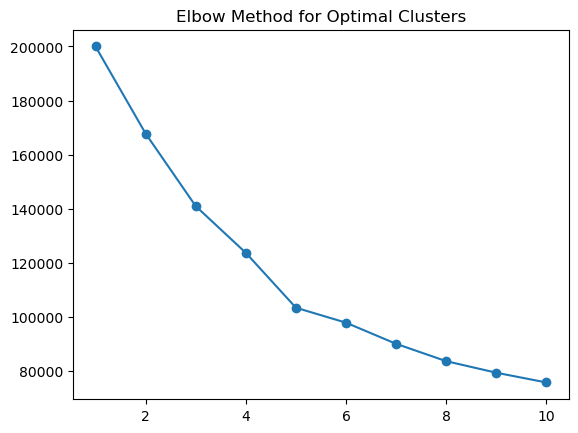

In [10]:
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal Clusters')
plt.show()

In [11]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [12]:
print(df.groupby('Cluster')[features].mean())

         sessions_per_week  avg_session_duration_min  \
Cluster                                                
0                 6.819084                 12.889506   
1                11.822406                 13.032504   
2                 6.780774                 13.594159   
3                 7.413302                 13.020686   

         feature_clicks_per_session  pages_viewed_per_session  
Cluster                                                        
0                         10.458651                  7.347291  
1                         11.469664                 13.520929  
2                         10.515859                 19.579503  
3                         16.616465                 13.435628  


In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

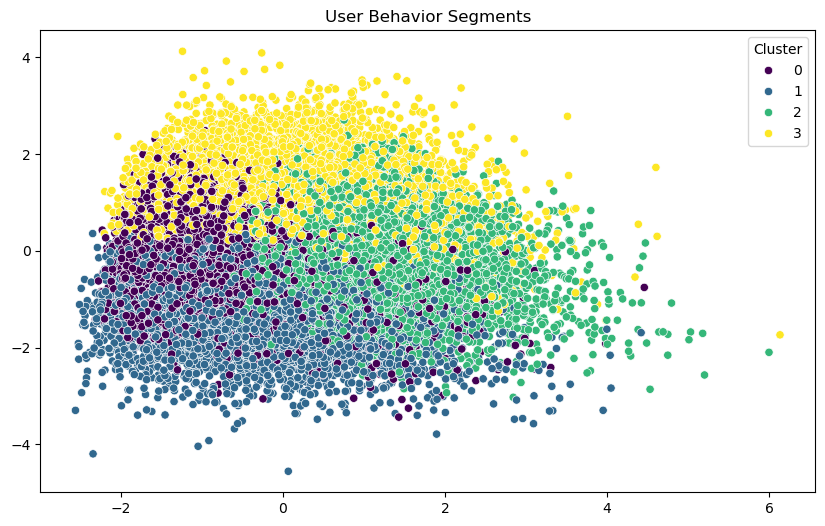

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], palette='viridis')
plt.title('User Behavior Segments')
plt.show()

In [15]:
df.to_csv('segmented_user_data.csv', index=False)